<a href="https://colab.research.google.com/github/Aritra0536G/Machine-Learning-mental-Health-prediction/blob/main/day5_mental_health_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
d=pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")

In [4]:
d

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [5]:
d.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [7]:
d.tail(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1190,17,female,3.8,Instagram,8.4,0.9,3.60,1.9,high,1,2,2,0
1191,19,male,8.0,TikTok,4.7,0.5,2.18,0.6,medium,8,8,6,1
1192,13,male,7.8,TikTok,5.9,1.5,3.31,1.9,high,10,1,10,0
1193,13,female,7.2,Instagram,8.1,2.1,2.52,0.4,medium,3,3,7,0
1194,17,male,2.0,Both,4.5,1.7,2.65,0.0,medium,9,4,2,0
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [6]:
d.shape

(1200, 13)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [9]:
#missing values .
#Here no missing value
d.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [10]:
d.duplicated().sum()

np.int64(0)

**EDA**

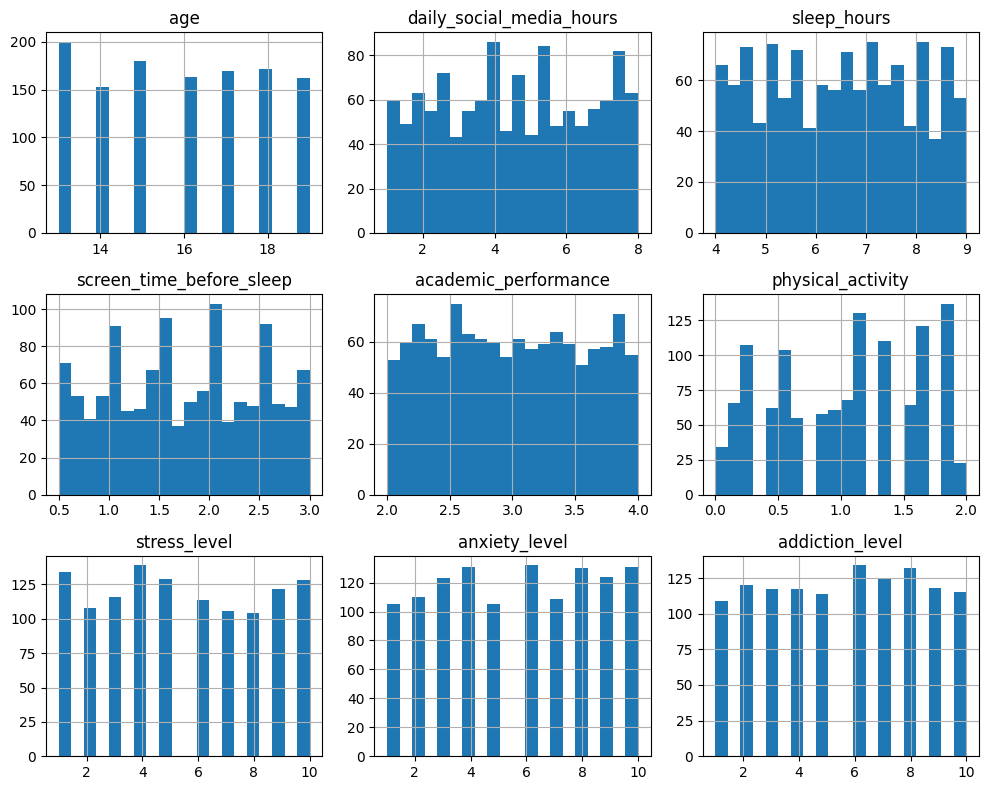

In [11]:
cols = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]

# Plot histograms
d[cols].hist(figsize=(10, 8), bins=20)

plt.tight_layout()
plt.show()

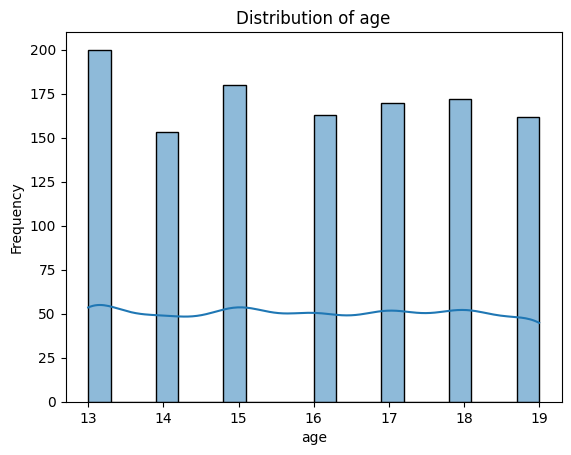

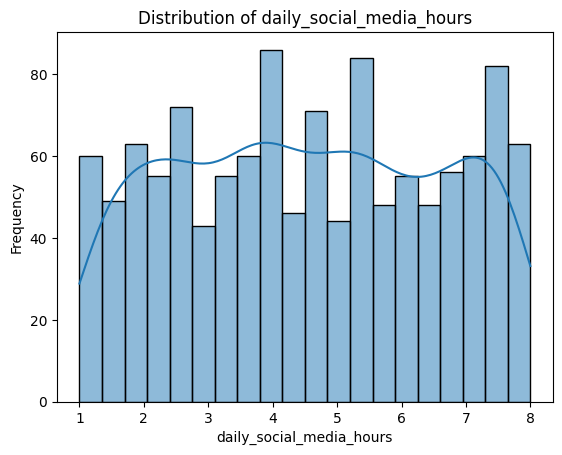

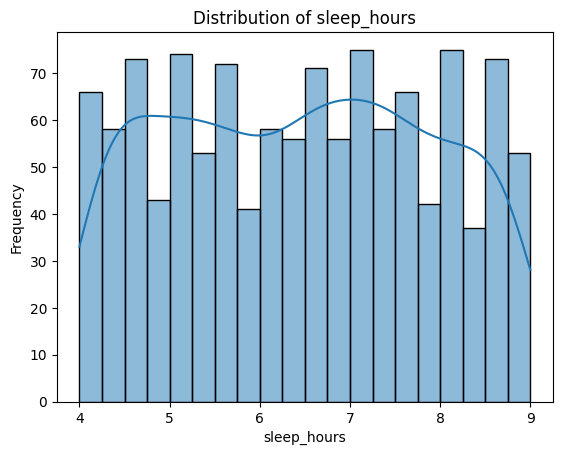

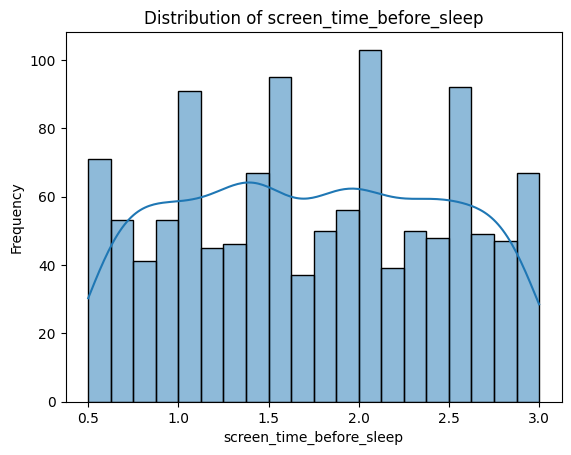

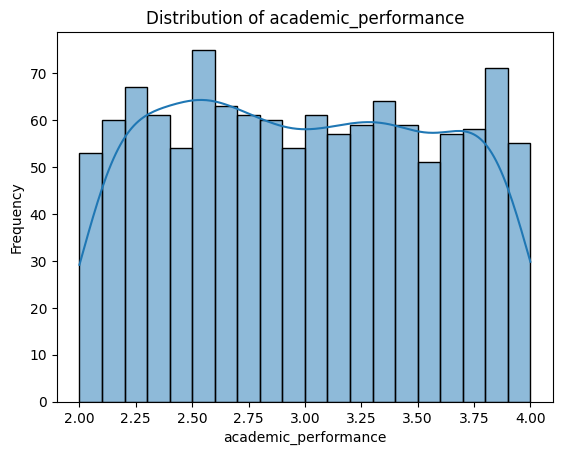

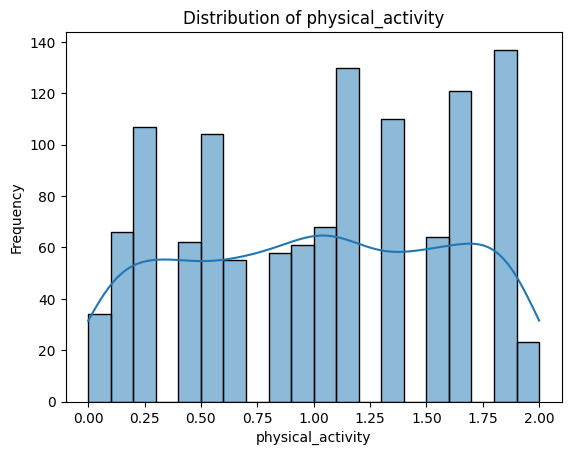

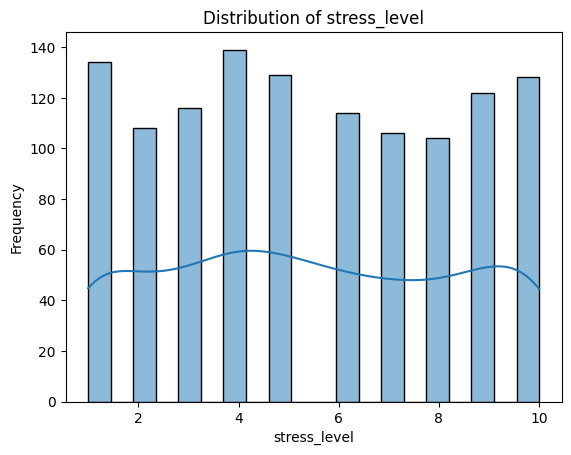

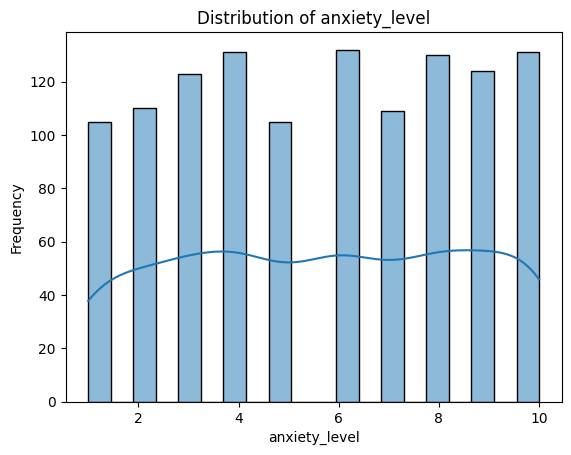

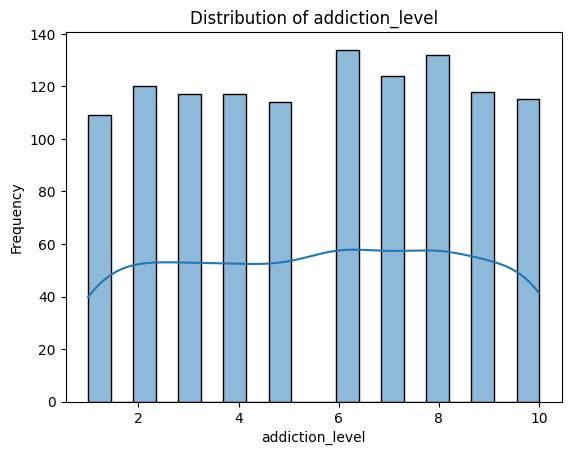

In [12]:
cols = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]

for col in cols:
    plt.figure()
    sns.histplot(d[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

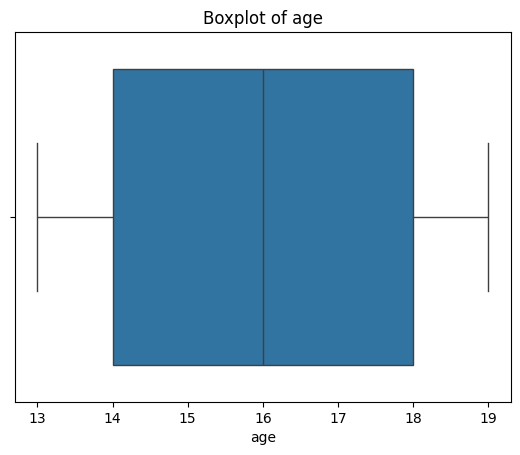

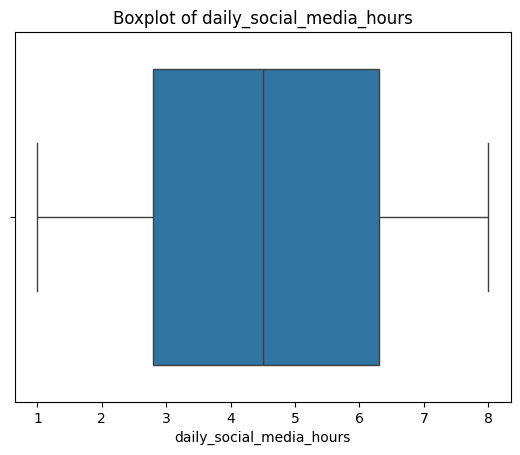

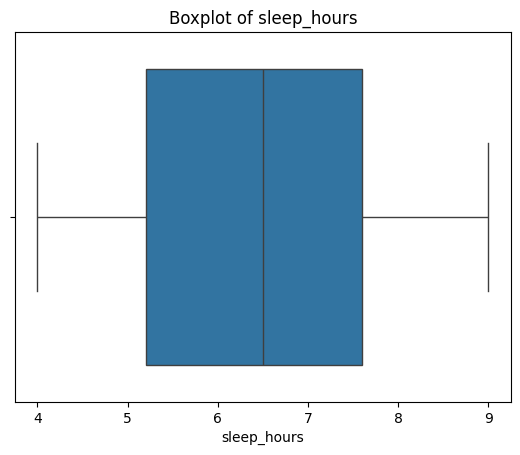

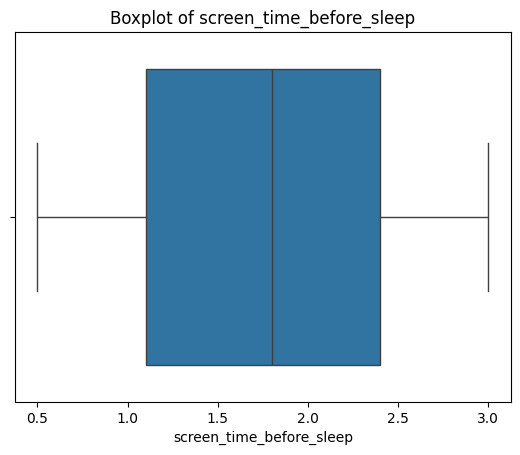

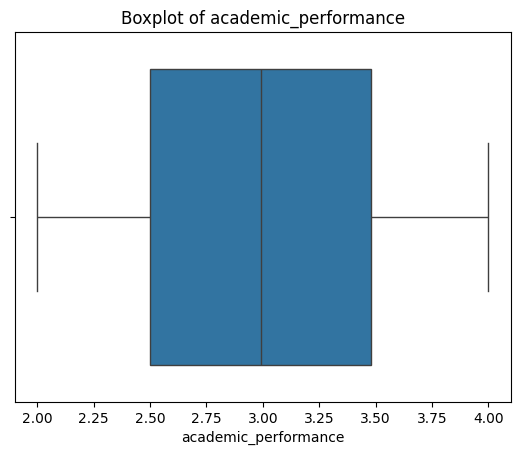

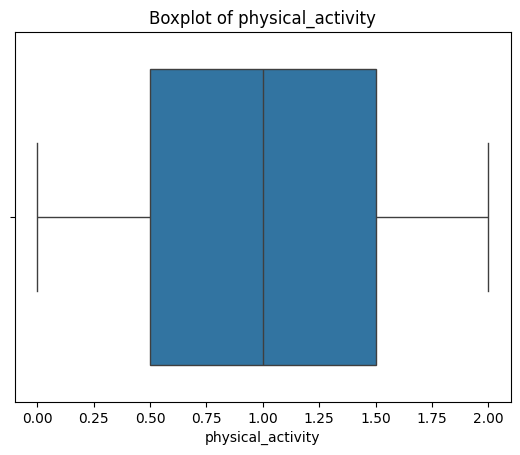

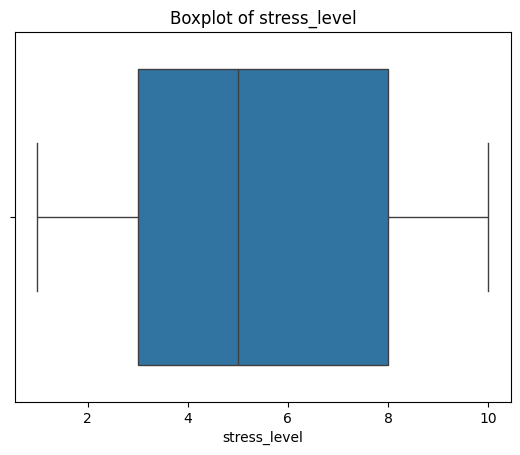

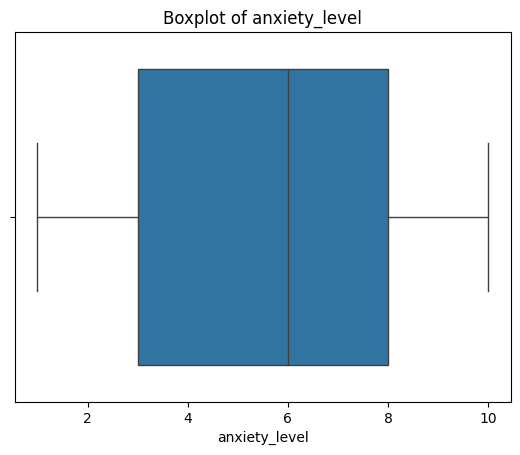

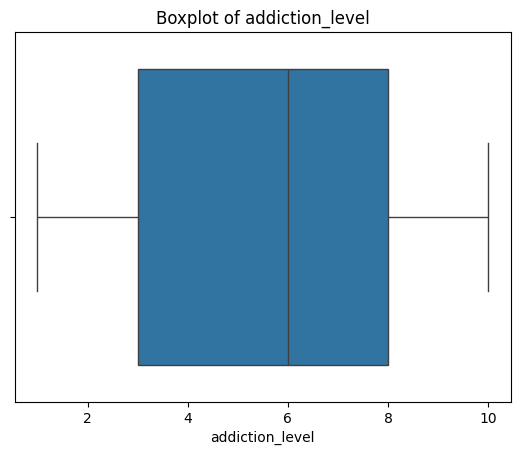

In [13]:
cols = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]

for col in cols:
    plt.figure()
    sns.boxplot(x=d[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [14]:
catagorical=['gender','platform_usage','social_interaction_level']
len(catagorical)

3

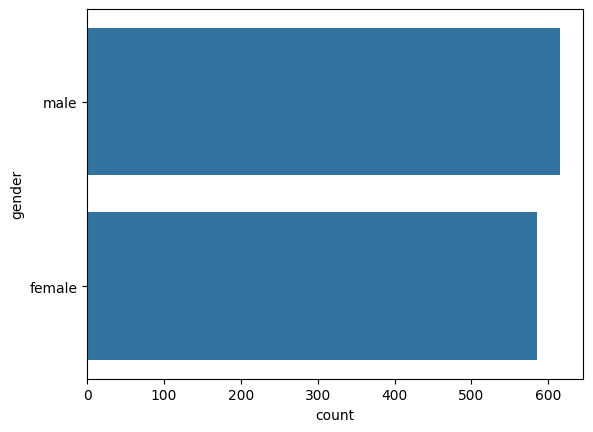

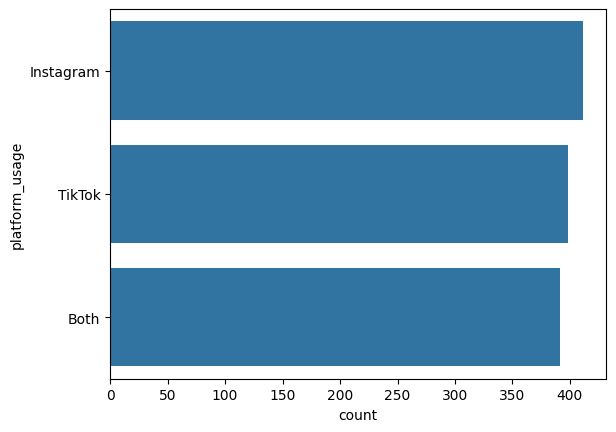

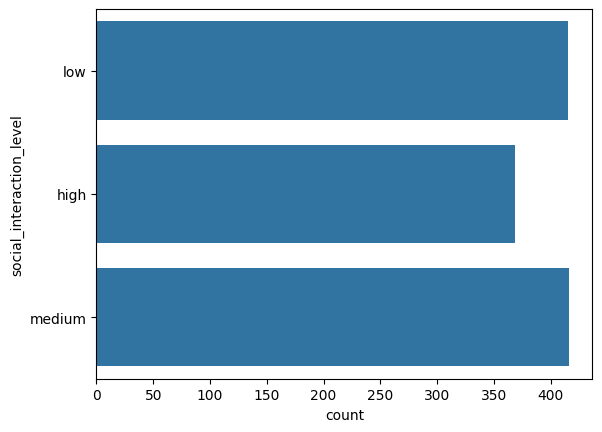

In [15]:
for i in catagorical:
  sns.countplot(d[i])
  plt.show()

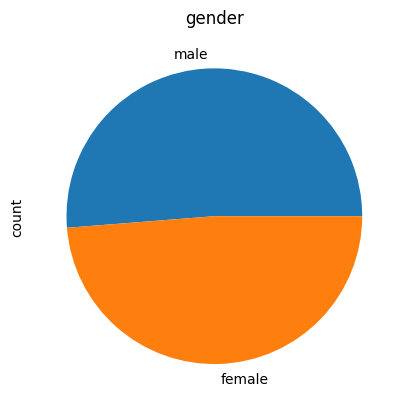

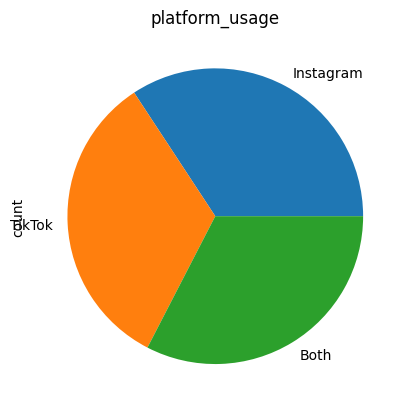

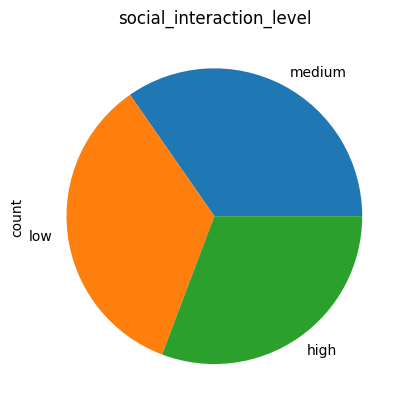

In [16]:
for i in catagorical:
  d[i].value_counts().plot(kind='pie')
  plt.title(i)
  plt.show()

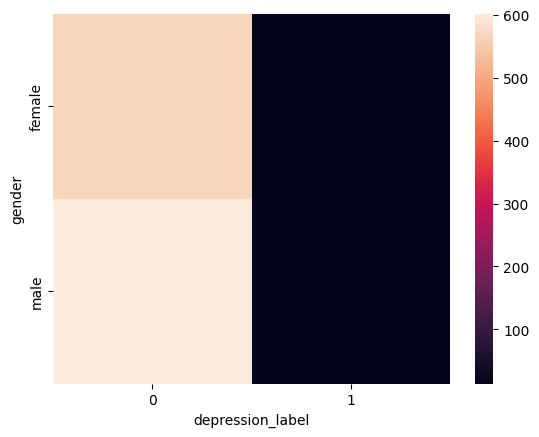

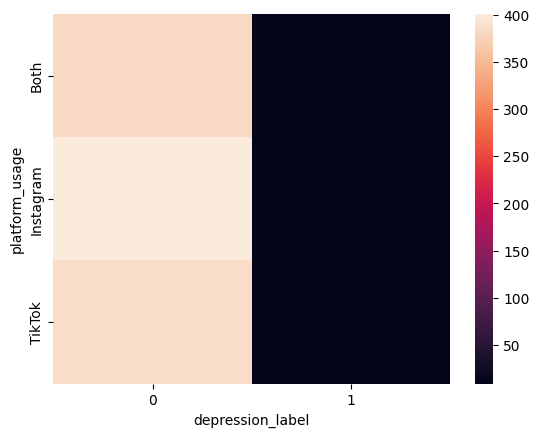

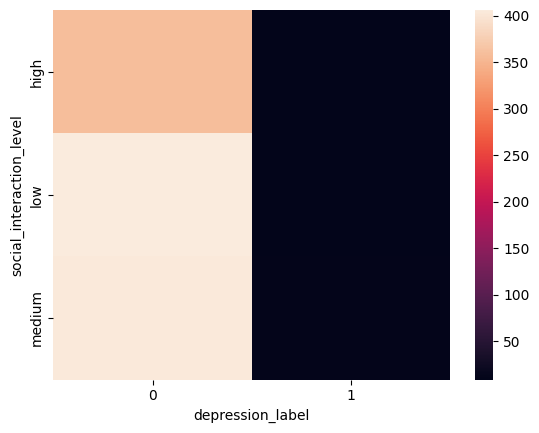

In [17]:
#heatmap
for i in catagorical:

  sns.heatmap(pd.crosstab(d[i],d['depression_label']))
  plt.show()

**SCALING**

In [18]:
x=d.drop('depression_label',axis=1)
y=d['depression_label']

In [19]:
x

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9


In [20]:
y

,depression_label
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,0
1198,0


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [22]:
x_train

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
331,16,female,6.1,Instagram,8.1,1.4,3.27,1.6,low,10,1,4
409,15,female,5.7,Instagram,7.5,2.4,2.84,1.3,medium,10,10,2
76,13,male,1.1,TikTok,7.1,1.8,2.55,0.8,high,5,5,10
868,16,female,5.3,TikTok,4.3,1.5,2.54,0.3,high,7,7,10
138,14,female,6.4,Instagram,6.0,1.1,3.81,0.9,medium,8,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1044,13,male,4.8,Instagram,6.0,0.6,2.41,0.0,high,3,6,9
1095,16,male,4.8,Instagram,8.6,1.8,2.44,1.7,high,8,7,3
1130,13,female,4.7,Both,6.8,1.4,3.91,0.8,high,10,6,9
860,15,male,3.5,TikTok,4.5,2.7,2.47,1.4,low,1,5,10


In [23]:
y_train

,depression_label
331,0
409,0
76,0
868,1
138,0
...,...
1044,0
1095,0
1130,0
860,0


In [24]:
x_test

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
1178,19,female,3.5,Instagram,4.9,0.5,3.68,1.7,high,8,4,3
865,15,male,6.5,TikTok,5.4,2.1,3.44,1.8,low,7,3,6
101,18,female,2.4,Instagram,6.3,1.3,3.05,1.7,low,2,9,5
439,13,female,2.4,Instagram,5.5,0.6,3.56,1.6,medium,4,8,7
58,13,male,7.3,Both,4.2,1.3,2.16,1.0,high,4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
382,15,female,4.2,TikTok,6.8,1.1,3.37,0.7,high,3,6,8
867,18,female,3.2,Both,7.8,0.7,3.46,1.3,low,5,10,6
542,18,female,2.1,Both,6.7,0.9,3.73,0.7,low,3,5,7
1193,13,female,7.2,Instagram,8.1,2.1,2.52,0.4,medium,3,3,7


In [25]:
y_test

,depression_label
1178,0
865,0
101,0
439,0
58,0
...,...
382,0
867,0
542,0
1193,0


In [27]:
d

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [28]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = make_column_transformer(
    (OneHotEncoder(drop='first'), ['gender','platform_usage','social_interaction_level']),
    (StandardScaler(), [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level'
    ])
)

In [31]:
x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

In [32]:
x_train

array([[ 0.        ,  1.        ,  0.        , ...,  1.56466523,
        -1.59878278, -0.55321941],
       [ 0.        ,  1.        ,  0.        , ...,  1.56466523,
         1.56002884, -1.25618517],
       [ 1.        ,  0.        ,  1.        , ..., -0.14185445,
        -0.1948665 ,  1.55567787],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.56466523,
         0.15611257,  1.20419499],
       [ 1.        ,  0.        ,  1.        , ..., -1.50707019,
        -0.1948665 ,  1.55567787],
       [ 1.        ,  0.        ,  1.        , ..., -0.82446232,
         1.56002884,  0.85271211]])

In [33]:
y_train

,depression_label
331,0
409,0
76,0
868,1
138,0
...,...
1044,0
1095,0
1130,0
860,0


In [34]:
L=LabelEncoder()
y_train=L.fit_transform(y_train)
y_test=L.transform(y_test)

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
M=RandomForestClassifier()
M.fit(x_train,y_train)

RandomForestClassifier()

In [37]:
from sklearn.metrics import accuracy_score
y_pred=M.predict(x_test)
accuracy_score(y_test,y_pred)

0.975